# Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import svd
from skimage.io import imread

# SVD for Image Compression - Black and white image

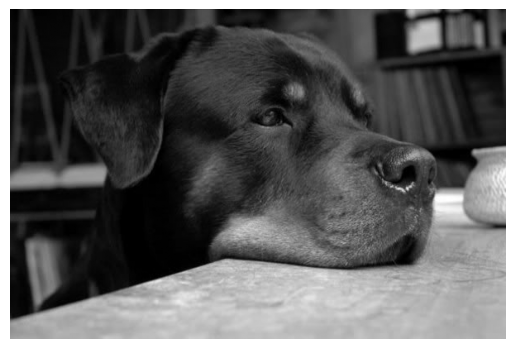

In [3]:
# Import the image
img = imread('/content/drive/MyDrive/ML/computational data mining/تمرین چهارم/rgb_dog.jpg', as_gray=True)

# Image size
x, y = img.shape

plt.imshow(img, cmap="gray")
plt.axis('off')
plt.show()

In [4]:
print(type(img))

<class 'numpy.ndarray'>


In [5]:
print(np.shape(img))

(399, 600)


In [6]:
# SVD decomposition
U, s, VT = svd(img, full_matrices=False)

print('Total singular values: {}.'.format(len(s)))

Total singular values: 399.


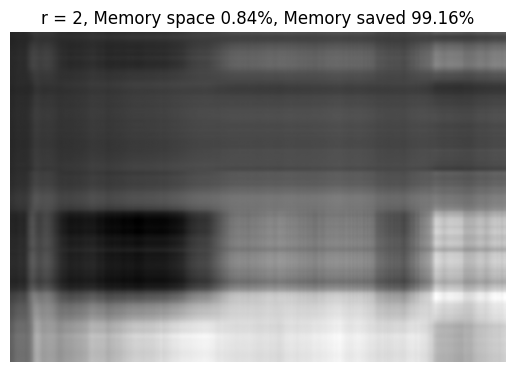

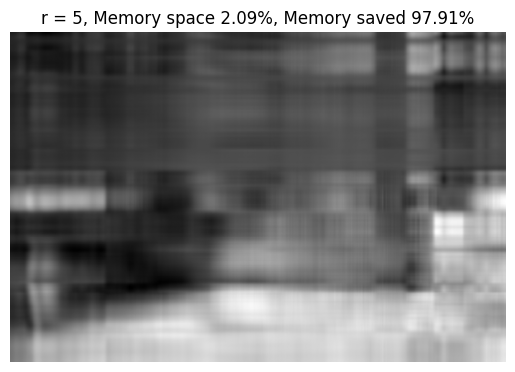

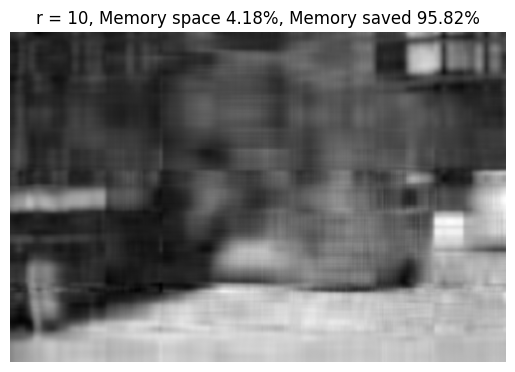

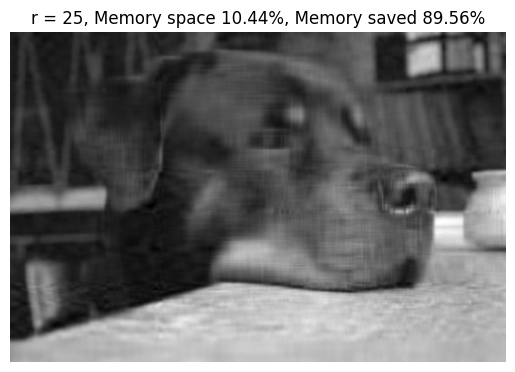

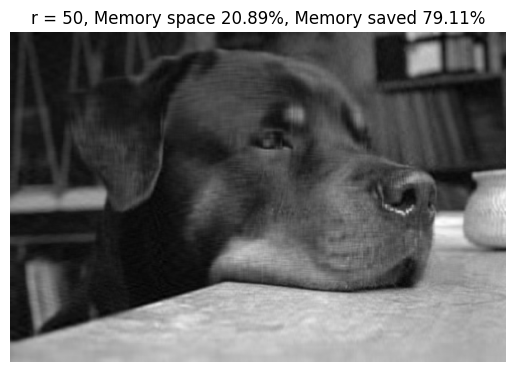

In [7]:
for r in 2, 5, 10, 25, 50:
    # r is the number of singular values used

    # Restoring the image
    img_reduce = U[:, :r] @ np.diag(s[:r]) @ VT[:r, :]

    plt.imshow(img_reduce, cmap="gray")
    plt.axis('off')
    #plt.title('r = ' + str(r) + ', Memory space {:.2%}'.format((x + y + 1) * r / (x * y)))
    plt.title('r = ' + str(r) +
              ', Memory space {:.2%}'.format((x + y + 1) * r / (x * y)) + ', Memory saved {:.2%}'.format(1 - ((x + y + 1) * r / (x * y))))
    plt.show()

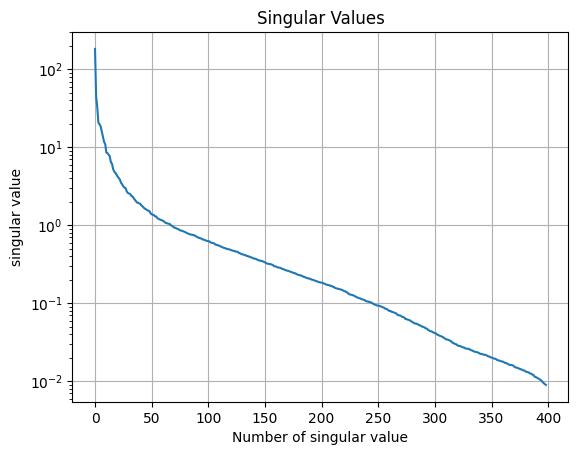

In [8]:
fig, ax = plt.subplots()

ax.semilogy(s)
ax.grid()
plt.title('Singular Values')
ax.set_xlabel('Number of singular value')
ax.set_ylabel('singular value')

plt.show()

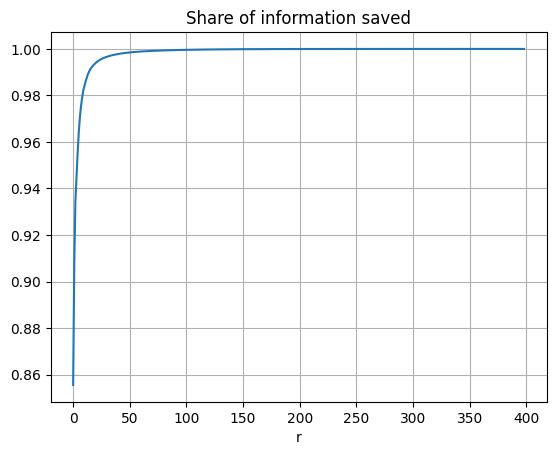

In [9]:
fig, ax = plt.subplots()

ax.plot(np.cumsum(s**2) / np.sum(s**2))
ax.grid()
plt.title('Share of information saved')
ax.set_xlabel('r')

plt.show()

variance Explained by Top 20 singular values:
[8.55552e-01 5.19420e-02 2.71590e-02 1.09570e-02 9.94200e-03 8.78500e-03
 6.54200e-03 4.75500e-03 3.54400e-03 3.09100e-03 1.87300e-03 1.82600e-03
 1.65800e-03 1.51300e-03 1.06900e-03 9.68000e-04 7.07000e-04 6.12000e-04
 5.64000e-04 5.06000e-04]


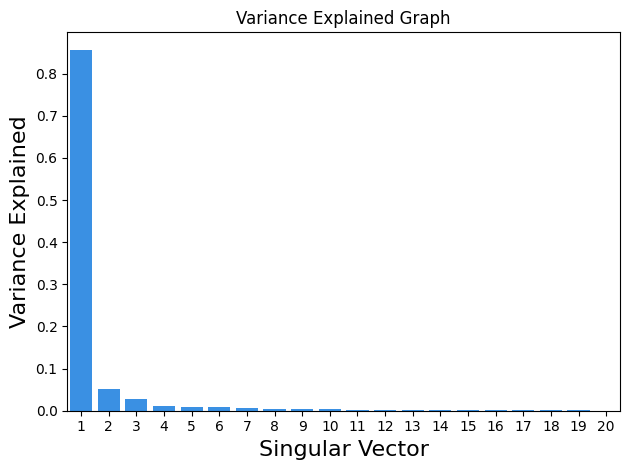

In [10]:
var_explained = np.round(s**2/np.sum(s**2), decimals=6)

# Variance explained top Singular vectors
print(f'variance Explained by Top 20 singular values:\n{var_explained[0:20]}')

sns.barplot(x=list(range(1, 21)),
            y=var_explained[0:20], color="dodgerblue")

plt.title('Variance Explained Graph')
plt.xlabel('Singular Vector', fontsize=16)
plt.ylabel('Variance Explained', fontsize=16)
plt.tight_layout()
plt.show()

# SVD for Image Compression - Color image

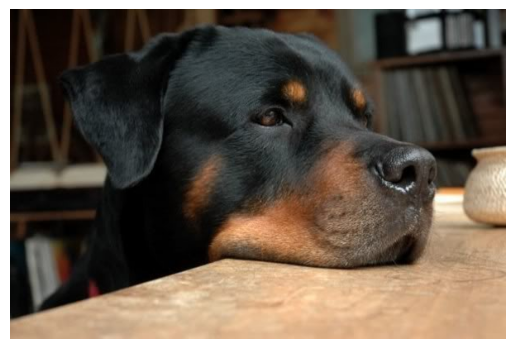

In [11]:
# Import the image
img_rgb = imread('/content/drive/MyDrive/ML/computational data mining/تمرین چهارم/rgb_dog.jpg')

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

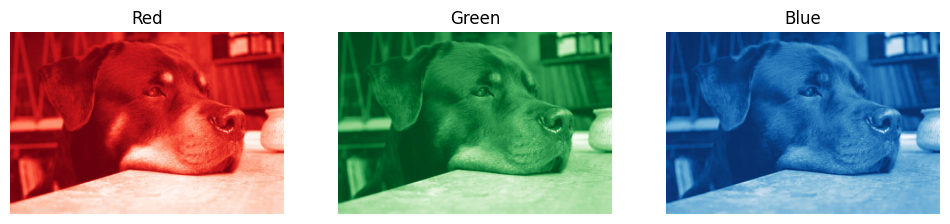

In [12]:
# Split the picture into Red, Green and Blue
img_r = img_rgb[:, :, 0]
img_g = img_rgb[:, :, 1]
img_b = img_rgb[:, :, 2]

# Picture the data obtained
fig, axes = plt.subplots(1, 3)

axes[0].imshow(img_r, cmap="Reds_r")
axes[0].axis('off')
axes[0].set_title('Red')

axes[1].imshow(img_g, cmap="Greens_r")
axes[1].axis('off')
axes[1].set_title('Green')

axes[2].imshow(img_b, cmap="Blues_r")
axes[2].axis('off')
axes[2].set_title('Blue')

fig.set_figwidth(12)
fig.set_figheight(6)

plt.show()

In [13]:
# SVD decomposition for Red, Green and Blue
U_r, s_r, VT_r = svd(img_r, full_matrices=False)
U_g, s_g, VT_g = svd(img_g, full_matrices=False)
U_b, s_b, VT_b = svd(img_b, full_matrices=False)

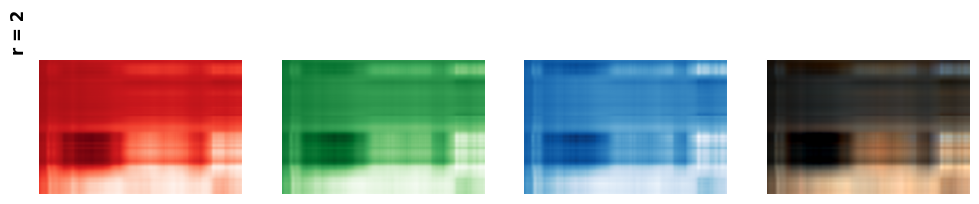

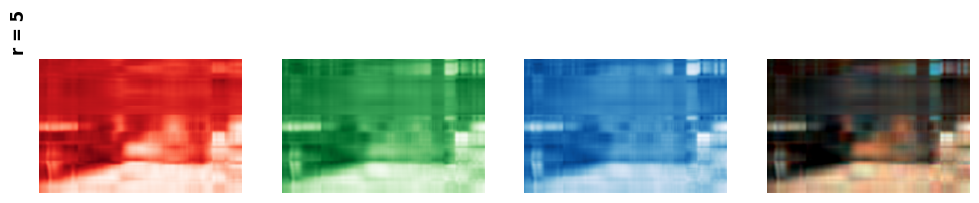

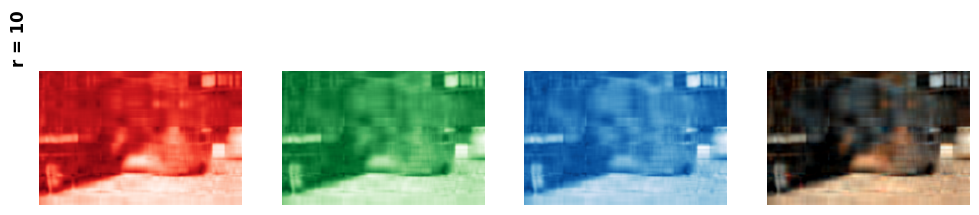

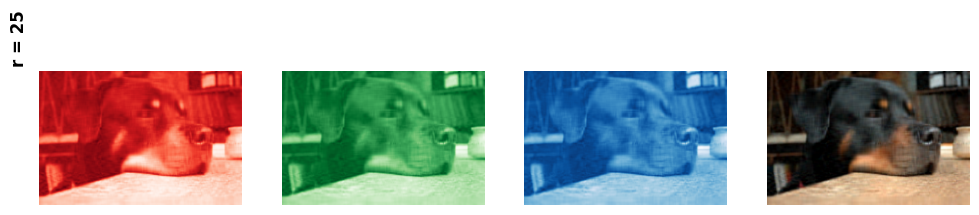

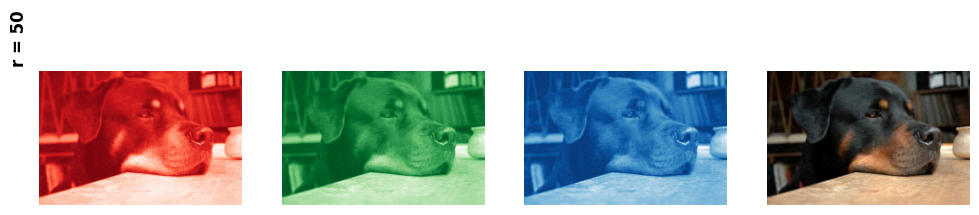

In [14]:
for r in 2, 5, 10, 25, 50:
    # r is the number of singular values used

    # Restoring the image
    img_reduce_r = U_r[:, :r] @ np.diag(s_r[:r]) @ VT_r[:r, :]
    img_reduce_g = U_g[:, :r] @ np.diag(s_g[:r]) @ VT_g[:r, :]
    img_reduce_b = U_b[:, :r] @ np.diag(s_b[:r]) @ VT_b[:r, :]

    fig, axes = plt.subplots(1, 4)

    axes[0].imshow(img_reduce_r, cmap="Reds_r")
    axes[0].axis('off')
    axes[0].set_title('r = ' + str(r), rotation="vertical",
                      position=(-.1, .42), fontweight='bold')

    axes[1].imshow(img_reduce_g, cmap="Greens_r")
    axes[1].axis('off')

    axes[2].imshow(img_reduce_b, cmap="Blues_r")
    axes[2].axis('off')

    img_reduce_rgb = np.stack(
        [img_reduce_r, img_reduce_g, img_reduce_b], axis=2)
    # Crop values to the range [0, 255]
    img_reduce_rgb[img_reduce_rgb < 0.] = 0
    img_reduce_rgb[img_reduce_rgb > 255.] = 255

    axes[3].imshow(img_reduce_rgb.astype('uint8'))
    axes[3].axis('off')

    fig.set_figwidth(12)
    fig.set_figheight(6)

    plt.show()